In [1]:
import os
import json
import glob
import numpy as np
from collections import defaultdict
from scipy.spatial.transform import Rotation as R

# -------------------- 디렉토리 설정 --------------------
# 각 pose에 해당하는 하위 데이터셋 디렉토리 경로 탐색
pose1_input_dirs = glob.glob("./franka_research3/frank_research3_ArUco_pose1/ArUco_capture_dataset_*")
pose2_input_dirs = glob.glob("./franka_research3/frank_research3_ArUco_pose2/ArUco_capture_dataset_*")

# 각 pose의 결과를 저장할 출력 디렉토리
output_dir_pose1 = "./franka_research3/frank_research3_correct_ArUco_pose1"
output_dir_pose2 = "./franka_research3/frank_research3_correct_ArUco_pose2"
os.makedirs(output_dir_pose1, exist_ok=True)
os.makedirs(output_dir_pose2, exist_ok=True)


# -------------------- 헬퍼 함수 (Helper Functions) --------------------

def parse_filename(filename):
    """파일 이름에서 view와 cam 정보를 추출합니다."""
    parts = filename.split('_')
    return parts[0], parts[2]

def average_quaternion(quaternions):
    """쿼터니언 배열의 평균을 계산합니다."""
    M = np.zeros((4, 4))
    for q in quaternions:
        q = q.reshape(4, 1)
        M += q @ q.T
    eigvals, eigvecs = np.linalg.eigh(M)
    avg_quat = eigvecs[:, np.argmax(eigvals)]
    return avg_quat / np.linalg.norm(avg_quat)

def angular_distance_deg(q1, q2):
    """두 쿼터니언 간의 각도 차이를 도(degree) 단위로 계산합니다."""
    r1 = R.from_quat(q1)
    r2 = R.from_quat(q2)
    relative_rot = r1.inv() * r2
    return np.rad2deg(relative_rot.magnitude())

def align_quaternions(quaternions):
    """쿼터니언의 부호를 정렬하여 평균 계산 시 발생할 수 있는 문제를 방지합니다."""
    aligned_quaternions = np.copy(quaternions)
    ref_quat = aligned_quaternions[0]
    for i in range(1, len(aligned_quaternions)):
        if np.dot(ref_quat, aligned_quaternions[i]) < 0:
            aligned_quaternions[i] *= -1
    return aligned_quaternions

def average_position(positions):
    """위치 벡터 배열의 평균을 계산합니다."""
    return np.mean(positions, axis=0)


# -------------------- 메인 처리 함수 --------------------

def process_pose_data(input_dirs, output_dir):
    """
    주어진 디렉토리에서 ArUco 데이터를 읽어와 보정한 후, 지정된 출력 디렉토리에 저장합니다.
    
    :param input_dirs: JSON 파일들이 포함된 디렉토리 경로 리스트
    :param output_dir: 보정된 JSON 파일을 저장할 디렉토리 경로
    """
    print(f"--- 데이터 처리 시작: {output_dir} ---")
    
    # 각 pose 처리를 위해 데이터를 새로 초기화
    data = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

    # 파일 수집 및 데이터 적재
    for base_dir in input_dirs:
        if not os.path.exists(base_dir):
            continue
        for fname in os.listdir(base_dir):
            if not fname.endswith('.json'):
                continue
            view, cam = parse_filename(fname)
            with open(os.path.join(base_dir, fname), 'r') as f:
                content = json.load(f)
                for marker_id, marker_data in content.items():
                    data[view][cam][marker_id].append(marker_data)
    
    # 마커 정리 및 저장
    for view in data:
        for cam in data[view]:
            corrected = {}
            for marker_id, entries in data[view][cam].items():
                if len(entries) < 2:
                    continue  # 최소 두 개 이상 있어야 평균 계산

                positions = [np.array([m['position_m']['x'], m['position_m']['y'], m['position_m']['z']]) for m in entries]
                quaternions = [np.array([m['rotation_quat']['x'], m['rotation_quat']['y'], m['rotation_quat']['z'], m['rotation_quat']['w']]) for m in entries]

                # 쿼터니언 정렬 후 초기 평균 계산
                aligned_quats = align_quaternions(np.array(quaternions))
                avg_quat_initial = average_quaternion(aligned_quats)

                # 이상치 제거 (평균에서 2도 이상 차이나는 데이터)
                filtered_positions = []
                filtered_quaternions = []
                for pos, quat in zip(positions, quaternions):
                    if angular_distance_deg(avg_quat_initial, quat) <= 2.0:
                        filtered_positions.append(pos)
                        filtered_quaternions.append(quat)
                    else:
                        print(f"이상치 감지: 마커 ID {marker_id} ({view}_{cam})")

                if not filtered_positions:
                    continue  # 이상치 제거 후 데이터가 없으면 건너뜀

                # 최종 평균 계산
                avg_pos = average_position(filtered_positions)
                # 최종 평균 계산 시에도 정렬된 쿼터니언 사용
                final_aligned_quats = align_quaternions(np.array(filtered_quaternions))
                avg_quat = average_quaternion(final_aligned_quats)

                corrected[marker_id] = {
                    "position_m": {"x": float(avg_pos[0]), "y": float(avg_pos[1]), "z": float(avg_pos[2])},
                    "rotation_quat": {"x": float(avg_quat[0]), "y": float(avg_quat[1]), "z": float(avg_quat[2]), "w": float(avg_quat[3])},
                    "corners_pixel": entries[0]["corners_pixel"]
                }

            # 해당 pose의 출력 디렉토리에 저장
            if corrected: # 처리된 데이터가 있을 경우에만 파일 생성
                output_path = os.path.join(output_dir, f"{view}_{cam}_corrected.json")
                with open(output_path, 'w') as f:
                    json.dump(corrected, f, indent=4)

    print(f"보정된 데이터가 다음 경로에 저장되었습니다: {output_dir}\n")


# -------------------- 메인 실행 블록 --------------------
if __name__ == "__main__":
    # Pose 1 데이터 처리
    process_pose_data(pose1_input_dirs, output_dir_pose1)
    
    # Pose 2 데이터 처리
    process_pose_data(pose2_input_dirs, output_dir_pose2)

    print("--- 모든 작업이 완료되었습니다. ---")

--- 데이터 처리 시작: ./franka_research3/frank_research3_correct_ArUco_pose1 ---
보정된 데이터가 다음 경로에 저장되었습니다: ./franka_research3/frank_research3_correct_ArUco_pose1

--- 데이터 처리 시작: ./franka_research3/frank_research3_correct_ArUco_pose2 ---
보정된 데이터가 다음 경로에 저장되었습니다: ./franka_research3/frank_research3_correct_ArUco_pose2

--- 모든 작업이 완료되었습니다. ---


In [2]:
import numpy as np
import os
import glob
import json
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

# -------------------- 설정값 --------------------
pose1_image_dir = "./frank_research3/frank_research3_ArUco_pose1/ArUco_capture_dataset_1"
pose2_image_dir = "./frank_research3/frank_research3_ArUco_pose2/ArUco_capture_dataset_1"
pose1_json_dir = "./frank_research3/frank_research3_ArUco_pose1/frank_research3_correct_ArUco"
pose2_json_dir = "./frank_research3/frank_research3_ArUco_pose2/frank_research3_correct_ArUco"
calib_dir = "./frank_research3/frank_research3_calib_cam_from_conf"
views = ['view1', 'view2', 'view3', 'view4']
cams = ['leftcam', 'rightcam']

# 시리얼 ↔ 위치 맵
camera_serials = {
    41182735: "view1", # front # marker 1, 2, 4, 5, 6
    49429257: "view2", # right # marker 2, 4, 7, 8
    44377151: "view3", # left  # marker 3, 5, 7, 8
    49045152: "view4"  # top   # marker 1, 2, 4, 6, 7, 8
}

serial_map = {v: k for k, v in camera_serials.items()}


marker_offsets = {
    "view1": {
        "1": np.array([0.025, 0.20, -0.01]), "2": np.array([-0.175, 0.0, -0.01]), "3": np.array([0.0, 0.0, 0.0]),
        "4": np.array([-0.30, 0.0, -0.01]), "5": np.array([0.35, 0.0, -0.01]), "6": np.array([0.025, 0.325, -0.01]),
        "7": np.array([0.0, 0.0, 0.0]), "8": np.array([0.0, 0.0, 0.0])
    },
    "view2": {
        "1": np.array([0.0, 0.00, 0.0]), "2": np.array([-0.175, 0.0, -0.01]), "3": np.array([0.0, 0.0, 0.0]),
        "4": np.array([-0.30, 0.00, -0.01]), "5": np.array([0.0, 0.0, 0.0]), "6": np.array([0.0, 0.0, 0.0]),
        "7": np.array([0.025, -0.225, -0.01]), "8": np.array([0.025, -0.325, -0.01])
    },
    "view3": {
        "1": np.array([0.0, 0.0, 0.0]), "2": np.array([0.0, 0.0, 0.0]), "3": np.array([0.225, 0.0, -0.01]),
        "4": np.array([0.0, 0.0, 0.0]), "5": np.array([0.35, 0.0, -0.01]), "6": np.array([0.0, 0.0, 0.0]),
        "7": np.array([0.025, -0.225, -0.01]), "8": np.array([0.025, -0.325, -0.01])
    },
    "view4": {
        "1": np.array([0.025, 0.20, -0.01]), "2": np.array([-0.175, 0.0, -0.01]), "3": np.array([0.0, 0.0, 0.0]),
        "4": np.array([-0.30, 0.01, -0.01]), "5": np.array([0.0, 0.0, 0.0]), "6": np.array([0.025, 0.325, -0.01]),
        "7": np.array([0.025, -0.225, -0.01]), "8": np.array([0.025, -0.325, -0.01])
    }
}

# -------------------- 결과 저장용 --------------------
summary = []
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale_axis = 0.3
font_scale_marker = 0.6
thickness_axis = 2
thickness_marker = 2

dist_coeffs_for_calc = np.zeros((5, 1))

marker_summary = []

for view in views:
    serial = serial_map[view]
    for cam in cams:
        pose_path = os.path.join(json_dir, f"{view}_{cam}_corrected.json")
        calib_path = os.path.join(calib_dir, f"{view}_{serial}_{cam}_calib.json")
        print(f"Processing {pose_path} and {calib_path}")
        
        if not (os.path.exists(pose_path) and os.path.exists(calib_path)):
            continue

        with open(pose_path) as f:
            poses = json.load(f)
        with open(calib_path) as f:
            calib = json.load(f)

        K = np.array(calib["camera_matrix"], dtype=np.float64)
        dist = np.array(calib["distortion_coeffs"], dtype=np.float64)

        # 마커별 좌표 리스트 생성
        pts_world = [(mid, np.array([p["position_m"]["x"], p["position_m"]["y"], p["position_m"]["z"]]))
                     for mid, p in poses.items() if mid in marker_offsets[view]]

        if not pts_world:
            continue

        base_positions = np.vstack([b for _, b in pts_world])
        mean_base = base_positions.mean(axis=0)
        std_base = base_positions.std(axis=0)

        # tvec, rvec 계산 (오프셋 적용 후)
        tvecs, marker_ids, quats, total = [], [], [], []
        for mid, offset in marker_offsets[view].items():
            # <--- 수정: offset이 0 벡터인 경우 계산에서 제외하는 조건 추가
            if mid not in poses or np.all(offset == 0):
                continue
            
            p = poses[mid]
            tvec = np.array([p["position_m"]["x"], p["position_m"]["y"], p["position_m"]["z"]])
            quat = np.array([p["rotation_quat"][k] for k in ("x", "y", "z", "w")])
            Rm = R.from_quat(quat).as_matrix()
            tvec_with_offset = tvec + Rm.dot(offset)
            tvecs.append(tvec_with_offset)
            quats.append(quat)
            marker_ids.append(mid)
            
        if not tvecs:
            continue
        
        mean_tvec = average_position(np.array(tvecs))
        avg_quat = average_quaternion(quats)
        # 2-3. 시각화를 위해 평균 쿼터니언을 회전 벡터(rvec)로 변환
        mean_rvec = R.from_quat(avg_quat).as_rotvec()
        
        # 이미지 로드
        img_files = glob.glob(os.path.join(image_dir, f"{view}_*_{cam}_*.png"))
        if not img_files:
            continue
        img = cv2.imread(img_files[0])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # 마커별 좌표축 및 ID 표시 (이제 0-offset 마커는 여기에 포함되지 않음)
        print("각 개별 마커의 자세를 시각화합니다...")
        for (quat, tvec, mid) in zip(quats, tvecs, marker_ids):
            rot_vec = R.from_quat(quat).as_rotvec()
            cv2.drawFrameAxes(img, K, dist_coeffs_for_calc, rot_vec, tvec.reshape(3, 1), 0.05)
            marker_pos_2d, _ = cv2.projectPoints(tvec.reshape(1, 3), np.zeros((3,1)), np.zeros((3,1)), K, dist_coeffs_for_calc)
            x_marker, y_marker = marker_pos_2d.ravel().astype(int)
            cv2.putText(img, f"ID:{mid}", (x_marker + 10, y_marker - 10), font, font_scale_marker, (255, 255, 0), thickness_marker)
            
        print("계산된 평균 자세를 시각화합니다...")
        # '평균' 회전축 그리기
        cv2.drawFrameAxes(img, K, dist_coeffs_for_calc, mean_rvec.reshape(3, 1), mean_tvec.reshape(3, 1), 0.05)

        # '평균' 위치(녹색 십자선)를 표시하기 위해 'mean_tvec'을 2D로 투영
        point_to_project = mean_tvec.reshape(1, 1, 3)
        projected_point, _ = cv2.projectPoints(point_to_project, np.zeros((3,1)), np.zeros((3,1)), K, dist_coeffs_for_calc)
        xm, ym = projected_point.ravel().astype(int)
        cv2.drawMarker(img, (xm, ym), (0, 255, 0), cv2.MARKER_CROSS, 20, 2)

        # '평균' 값에 대한 텍스트 정보 표시
        mean_rvec_deg = np.rad2deg(mean_rvec)
        rvec_text = f"Rvec [deg]: {mean_rvec_deg[0]:.1f}, {mean_rvec_deg[1]:.1f}, {mean_rvec_deg[2]:.1f}"
        cv2.putText(img, rvec_text, (xm + 5, ym + 20), font, 0.5, (0, 255, 255), 2)

        # 시각화
        plt.figure(figsize=(16, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{view.upper()} - {cam}")
        plt.show()
        
        summary.append([view, cam, *mean_base, *std_base, xm, ym, *mean_tvec, *mean_rvec])
        
        total.append(marker_ids)
        total.append(tvecs)
        total.append(mean_tvec)
        total.append(quats)
        total.append(mean_rvec)
        marker_summary.append(total)
# -------------------- 결과 저장 --------------------
columns = ["view", "cam", "mean_x", "mean_y", "mean_z",
           "std_x", "std_y", "std_z", "proj_x", "proj_y",
           "tvec_x", "tvec_y", "tvec_z",
           "rvec_x", "rvec_y", "rvec_z"]
df = pd.DataFrame(summary, columns=columns)

pose1_output_dir = "./pose1_summary"
pose2_output_dir = "./pose2_summary"

os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "aruco_pose_summary.json")
df.to_json(output_path, orient="records", indent=2)

NameError: name 'json_dir' is not defined

In [ ]:
marker_summary

[[['1', '2', '4', '5', '6'],
  [array([0.15811819, 0.36350302, 0.78495983]),
   array([0.15445206, 0.37373839, 0.80640523]),
   array([0.15373953, 0.38616989, 0.80002399]),
   array([0.15599126, 0.35681709, 0.79033517]),
   array([0.15514472, 0.36287868, 0.78162763])],
  array([0.15548915, 0.36862141, 0.79267037]),
  [array([ 0.00799952, -0.72975586, -0.68365865, -0.00179989]),
   array([ 0.00140001, -0.72690649, -0.68670613, -0.00630006]),
   array([ 0.03549807, -0.59916746, -0.79975657,  0.01129939]),
   array([ 0.00870031, -0.72222566, -0.69152457,  0.01040037]),
   array([ 0.01219984, -0.73199029, -0.68119096, -0.00449994])],
  array([ 0.04126684, -2.20891515, -2.22842806])],
 [['1', '2', '4', '5', '6'],
  [array([0.03754322, 0.364367  , 0.78604366]),
   array([0.02851343, 0.38601024, 0.80605834]),
   array([0.04016456, 0.34925986, 0.78349888]),
   array([0.03256623, 0.35669841, 0.78606446]),
   array([0.03587562, 0.36452097, 0.7835933 ])],
  array([0.03493261, 0.3641713 , 0.789051

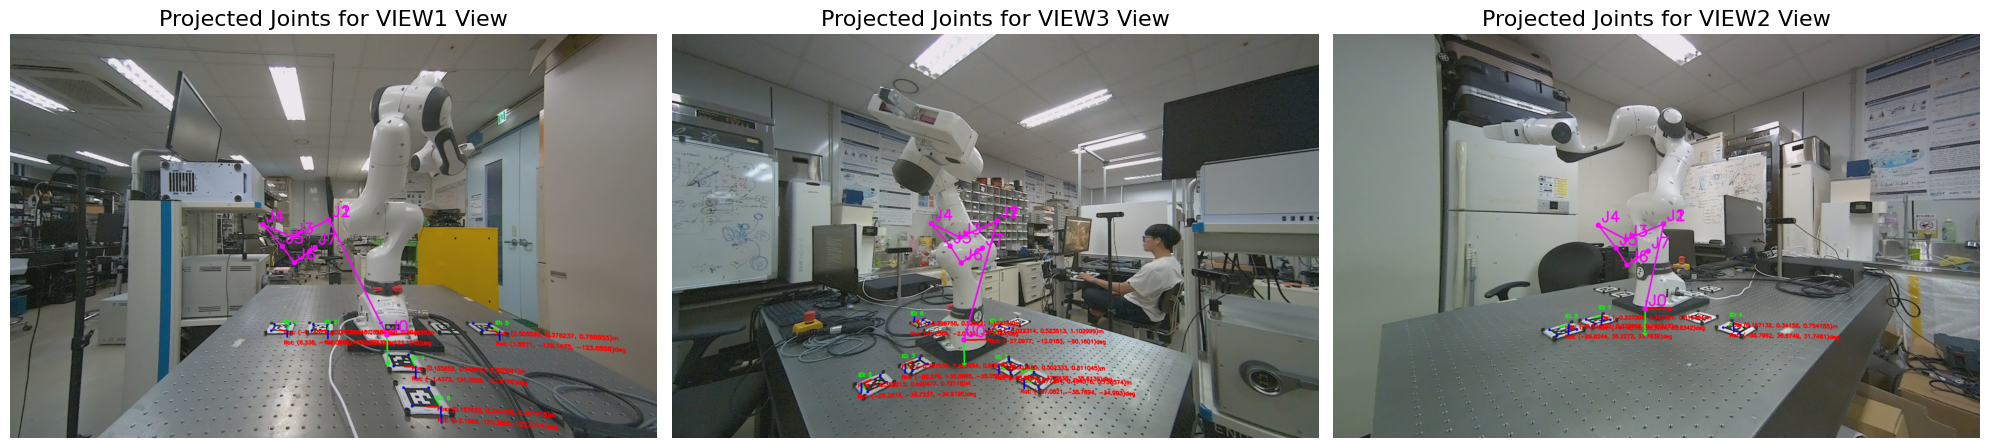

In [ ]:
import os
import json
import math
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

# ---------------------- ArUco 결과 및 데이터 경로 ----------------------
aruco_path = './result_output/aruco_pose_summary.json'
with open(aruco_path, 'r') as f:
    aruco_results_all = json.load(f)

image_paths = [
    "/home/najo/NAS/DIP/Panda_cap_make_dataset/ArUco_cap_panda/front_41182735_leftcam_2025-08-26_14-18-15.png",
    "/home/najo/NAS/DIP/Panda_cap_make_dataset/ArUco_cap_panda/left_44377151_leftcam_2025-08-26_14-20-05.png",
    "/home/najo/NAS/DIP/Panda_cap_make_dataset/ArUco_cap_panda/right_49429257_rightcam_2025-08-26_14-19-14.png"
]
joint_data_path = "/home/najo/NAS/DIP/datasets/Fr5_intertek_dataset/Fr5_intertek_6th_250526/joint/joint_30779426_1748249285.123.json"

# ---------------------- 조인트 데이터 로드 ----------------------
with open(joint_data_path, 'r') as f:
    joint_angles = json.load(f)

joint_angles = [0,-30,30,-30,30,30,45]
# ---------------------- DH 변환 행렬 계산 함수 ----------------------
def get_dh_matrix(a, d, alpha, theta):
    alpha_rad = math.radians(alpha)
    theta_rad = math.radians(theta)
    return np.array([
        [np.cos(theta_rad), -np.sin(theta_rad) * np.cos(alpha_rad),  np.sin(theta_rad) * np.sin(alpha_rad), a * np.cos(theta_rad)],
        [np.sin(theta_rad),  np.cos(theta_rad) * np.cos(alpha_rad), -np.cos(theta_rad) * np.sin(alpha_rad), a * np.sin(theta_rad)],
        [0, np.sin(alpha_rad), np.cos(alpha_rad), d],
        [0, 0, 0, 1]
    ])

# ---------------------- 조인트 각도를 카메라 좌표계 내 조인트 위치로 변환 ----------------------
def angle_to_joint_coordinate(joint_angles, selected_view):
    # FR5 DH parameters (degrees and meters)
    fr5_dh_parameters = [
        {'alpha': -90,  'a': 0,     'd': 0.333, 'theta': 0},
        {'alpha': 90,   'a': 0,     'd': 0,     'theta': 0},
        {'alpha': 90,   'a': 0.0825,'d': 0.316, 'theta': 0},
        {'alpha': -90,  'a':-0.0825,'d': 0,     'theta': 0},
        {'alpha': 90,   'a': 0,     'd': 0.384, 'theta': 0},
        {'alpha': 0,    'a': 0.088, 'd': 0,     'theta': 0},
        {'alpha': 0,    'a': 0,     'd': 0.107, 'theta': 0}
    ]
    joint_coords_3d = [np.array([0, 0, 0])] # J0 (베이스)

    # 카메라 뷰에 따른 베이스 좌표계 보정 회전 정의
    view_rotations = {
        'top': R.from_euler('zyx', [-90, 0, 180], degrees=True),
        'left': R.from_euler('zyx', [180, 0, 92], degrees=True),
        'right': R.from_euler('zyx', [0, 0, 95], degrees=True)
    }
    
    T_base_correction = np.eye(4)
    if selected_view in view_rotations:
        T_base_correction[:3, :3] = view_rotations[selected_view].as_matrix()

    T_cumulative = T_base_correction
    base_point = np.array([[0], [0], [0], [1]])
    for i in range(len(joint_angles)):
        params = fr5_dh_parameters[i]
        theta = joint_angles[i] + params['theta']
        T_i = get_dh_matrix(params['a'], params['d'], params['alpha'], theta)
        T_cumulative = T_cumulative @ T_i
        joint_pos = T_cumulative @ base_point
        joint_coords_3d.append(joint_pos[:3, 0])
    return np.array(joint_coords_3d, dtype=np.float32)

# ---------------------- 3D 조인트 좌표를 이미지 평면에 투영 ----------------------
def joint_coordinate_to_pixel_plane(joint_coords, aruco_result, camera_matrix, dist_coeffs):
    Rvec = np.array([
        math.radians(aruco_result['rvec_x']),
        math.radians(aruco_result['rvec_y']),
        math.radians(aruco_result['rvec_z'])
    ], dtype=np.float32)
    Tvec = np.array([
        aruco_result['tvec_x'],
        aruco_result['tvec_y'],
        aruco_result['tvec_z']
    ], dtype=np.float32).reshape(3, 1)

    pixel_coords, _ = cv2.projectPoints(
        joint_coords, Rvec, Tvec*0.001, camera_matrix, dist_coeffs
    )
    return pixel_coords.reshape(-1, 2)

# ---------------------- 개별 뷰를 처리하고 플롯하는 함수 ----------------------
def plot_view(image_path, joint_angles, aruco_results_all):
    image_name = os.path.basename(image_path)
    parts = image_name.split('_')

    serial_str = parts[1]
    serial_to_view = {
        '41182735': "view1", # front
        '49429257': "view2", # right
        '44377151': "view3", # left
        '49045152': "view4"  # top
    }

    selected_view = serial_to_view[serial_str]
    
    # <<< FIX 1: Do not add "cam" suffix, as it's already in the filename.
    selected_cam = parts[2]

    # Find the matching result from the ArUco summary JSON
    aruco_result = next(
        item for item in aruco_results_all 
        if item['view'] == selected_view and item['cam'] == selected_cam
    )

    # Load the correct calibration file
    calib_dir = "./Calib_cam_from_conf"
    
    # <<< FIX 2: The calibration path needs the serial number (serial_str), not the view name.
    calib_path = os.path.join(calib_dir, f"{selected_view}_{serial_str}_{selected_cam}_calib.json")

    with open(calib_path, 'r') as f:
        calib = json.load(f)

    camera_matrix = np.array(calib["camera_matrix"], dtype=np.float32)
    dist_coeffs = np.array(calib["distortion_coeffs"], dtype=np.float32)

    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    undistorted = cv2.undistort(image_rgb, camera_matrix, dist_coeffs)

    # --- The rest of your function remains the same ---
    joint_coords = angle_to_joint_coordinate(joint_angles, selected_view)
    pixel_coords = joint_coordinate_to_pixel_plane(joint_coords, aruco_result, camera_matrix, dist_coeffs)

    aruco_axis_length = 0.1
    aruco_axis_points = np.array([
        [0, 0, 0],
        [aruco_axis_length, 0, 0],
        [0, aruco_axis_length, 0],
        [0, 0, aruco_axis_length]
    ], dtype=np.float32)

    Rvec = np.array([
        math.radians(aruco_result['rvec_x']),
        math.radians(aruco_result['rvec_y']),
        math.radians(aruco_result['rvec_z'])
    ], dtype=np.float32)
    Tvec = np.array([
        aruco_result['tvec_x'],
        aruco_result['tvec_y'],
        aruco_result['tvec_z']
    ], dtype=np.float32).reshape(3, 1)

    projected_axes, _ = cv2.projectPoints(
        aruco_axis_points, Rvec, Tvec, camera_matrix, dist_coeffs
    )
    projected_axes = projected_axes.reshape(-1, 2).astype(int)

    origin_aruco = tuple(projected_axes[0])
    x_end_aruco = tuple(projected_axes[1])
    y_end_aruco = tuple(projected_axes[2])
    z_end_aruco = tuple(projected_axes[3])

    image_with_axes = undistorted.copy()
    cv2.arrowedLine(image_with_axes, origin_aruco, x_end_aruco, (255, 0, 0), 3) # X - Red
    cv2.arrowedLine(image_with_axes, origin_aruco, y_end_aruco, (0, 255, 0), 3) # Y - Green
    cv2.arrowedLine(image_with_axes, origin_aruco, z_end_aruco, (0, 0, 255), 3) # Z - Blue

    font = cv2.FONT_HERSHEY_SIMPLEX
    for idx, (x, y) in enumerate(pixel_coords.astype(int)):
        text = f"J{idx}"
        cv2.circle(image_with_axes, (x, y), 8, (255, 0, 255), -1)
        cv2.putText(image_with_axes, text, (x + 10, y - 10), font, 1.5, (255, 0, 255), 3)
        
        if idx > 0:
            prev_x, prev_y = pixel_coords[idx-1].astype(int)
            cv2.line(image_with_axes, (prev_x, prev_y), (x, y), (255, 0, 255), 4)

    return image_with_axes, selected_view

# ---------------------- 메인 실행부 ----------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

for i, image_path in enumerate(image_paths):
    try:
        image_with_axes, selected_view = plot_view(image_path, joint_angles, aruco_results_all)
        ax = axes[i]
        ax.imshow(image_with_axes)
        ax.axis("off")
        ax.set_title(f"Projected Joints for {selected_view.upper()} View", fontsize=16)
    except FileNotFoundError as e:
        print(e)
        axes[i].set_title(f"Image not found for view {selected_view}", fontsize=12)
        axes[i].axis("off")

plt.tight_layout()
plt.show()